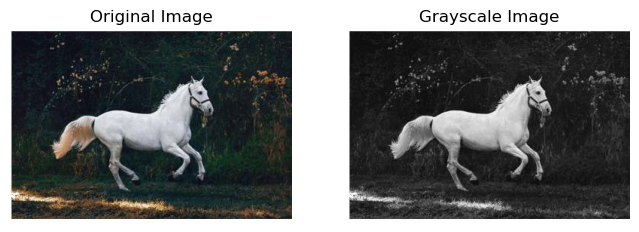

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load image
image = cv2.imread('horse.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [3]:
# Reshape into pixel list
pixel_values = image_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)
print("Shape of pixel array:", pixel_values.shape)

Shape of pixel array: (96000, 3)


In [5]:
# Apply K-Means
k = 2
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(pixel_values) #a grid the same size as the image, where each value is the 'bucket' the corresponding pixel belongs to
centers = np.uint8(kmeans.cluster_centers_) #average color of each pixel
print("Cluster centers:\n", centers)

Cluster centers:
 [[201 199 198]
 [ 30  37  36]]


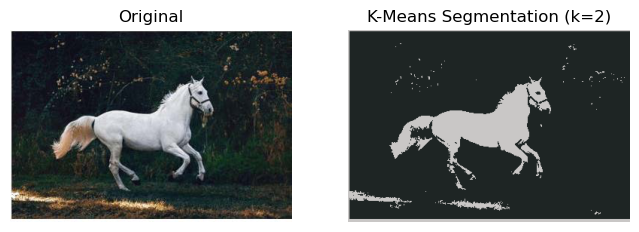

In [7]:
# Reconstruct segmented image
segmented_image = centers[labels.flatten()] #make labels into a 1D array, and replace each label with the corresponding center color
segmented_image = segmented_image.reshape(image_rgb.shape)
# Display
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis('off')
plt.subplot(1,2,2)
plt.title(f"K-Means Segmentation (k={k})")
plt.imshow(segmented_image)
plt.axis('off')
plt.show()

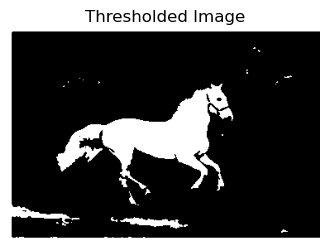

In [8]:
# Preprocessing: remove small fluctuations (noise)
blur = cv2.GaussianBlur(gray, (3,3), 0)
# Thresholding (separate foreground and background),
# this converts image to binary and gives a rough idea of where objects are (initial guess)
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) #converting blurred image to a black&white image, whereby pixels above a certain threshold are set to white, and those below are set to black. The threshold is automatically determined using Otsu's method.
plt.figure(figsize=(4,4))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

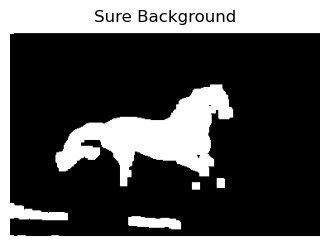

In [ ]:
# Morphological Opening (this romoves small white noise in the mask)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2) #removes noise by eroding the image and then dilating it back to its original size. The number of iterations determines how aggressive the opening is.
# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=2) #makes white areas bigger, so that we are sure to include all of the background (but may also include some foreground)
plt.figure(figsize=(4,4))
plt.imshow(sure_bg, cmap='gray')
plt.title("Sure Background")
plt.axis('off')
plt.show()

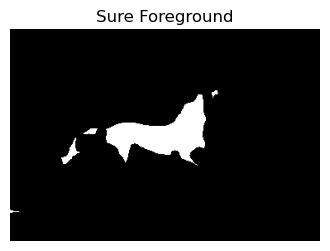

In [ ]:
# Distance transform (find object centers)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5) #calculates the distance from white pixels to nearest black boundary. This helps to identify the central regions of objects, which are likely to be the most distinct and less likely to be affected by noise.
# Sure foreground (keeps only the central parts of objects, high-confidence regions)
_, sure_fg = cv2.threshold(dist_transform,
0.2*dist_transform.max(), 255, 0) #keeps only pixels that are at least 20% of the maximum distance from the boundary, which are likely to be the most central and distinct parts of the objects.
plt.figure(figsize=(4,4))
plt.imshow(sure_fg, cmap='gray')
plt.title("Sure Foreground")
plt.axis('off')
plt.show()

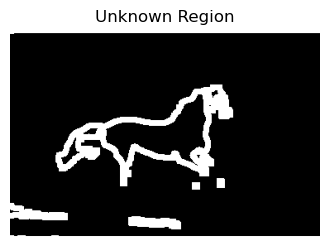

In [11]:
# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
plt.figure(figsize=(4,4))
plt.imshow(unknown, cmap='gray')
plt.title("Unknown Region")
plt.axis('off')
plt.show()

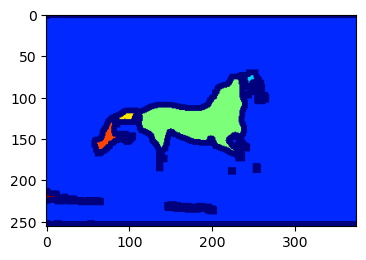

In [12]:
# Markers
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
plt.figure(figsize=(4,4))
plt.imshow(markers, cmap='jet')

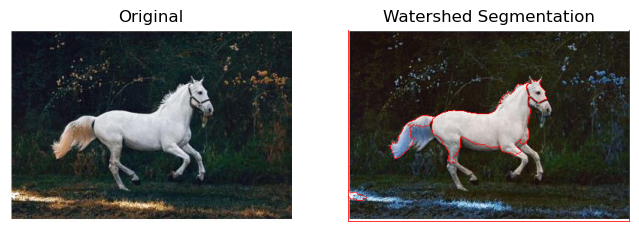

In [ ]:
# Apply Watershed (floods from markers, regions expand until they meet)
image_ws = image.copy()
markers = cv2.watershed(image_ws, markers) #floods from markers, boundarie are created where different regions meet.
image_ws[markers == -1] = [255, 0, 0] #mark boundaries in red
# Display
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Watershed Segmentation")
plt.imshow(image_ws)
plt.axis('off')
plt.show()

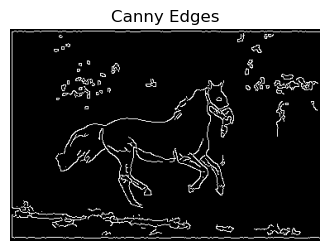

In [14]:
# Smooth image
blur = cv2.GaussianBlur(gray, (5, 5), 0)
# Edge detection
edges = cv2.Canny(blur, 50, 150)
plt.figure(figsize=(4,4))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')
plt.show()

In [15]:
# Find contours
contours, _ = cv2.findContours(
edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
print("Number of contours:", len(contours))

Number of contours: 98


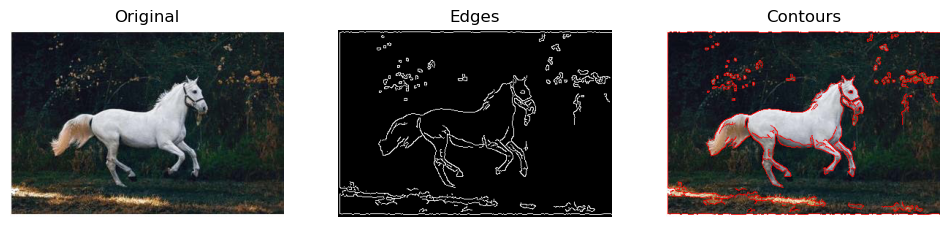

In [16]:
# Draw contours
contour_image = image_rgb.copy()
cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 1)
# Display results
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis('off')
plt.subplot(1,3,2)
plt.title("Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title("Contours")
plt.imshow(contour_image)
plt.axis('off')
plt.show()